In [1]:
import pandas as pd 

df=pd.read_csv("Bengaluru_House_Data.csv")
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 1.6 MB


In [3]:
for col in df.columns:
    print(df[col].value_counts())

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64
availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
15-Aug               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64
location
Whitefield                                         540
Sarjapur  Road                                     399
Electronic City                                    302
Kanakpura Road                                     273
Thanisandra                                        234
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                       

In [4]:
df.isnull().sum() # df.isna().sum() 

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [5]:
df.drop(columns=['area_type', 'availability', 'society'],inplace=True)

In [6]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


<Axes: >

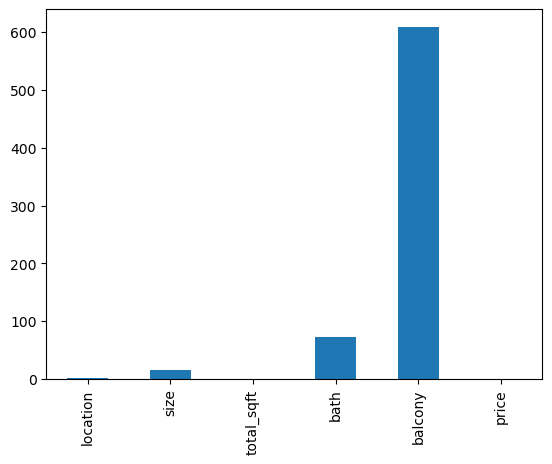

In [7]:
missing_values = df.isnull().sum()
missing_values.plot(kind='bar')

In [8]:
from sklearn.impute import SimpleImputer

for col in df.columns[df.isnull().any()]:
    if df[col].dtype in ['float64','int64','int32']:
        imputer=SimpleImputer(strategy='median')
    else:
        imputer=SimpleImputer(strategy='most_frequent')
    df[col]=imputer.fit_transform(df[[col]]).ravel()

df.isna().sum()

location      0
size          0
total_sqft    0
bath          0
balcony       0
price         0
dtype: int64

In [9]:
df['total_sqft'].unique()

<ArrowStringArray>
[       '1056',        '2600',        '1440',        '1521',        '1200',
        '1170',        '2732',        '3300',        '1310',        '1020',
 ...
        '3124',        '9200',         '613',         '250',        '2395',
 '1020 - 1130',        '2758', '1133 - 1384',         '774',        '4689']
Length: 2117, dtype: str

In [10]:
def convert(value):
    temp = value.split('-')
    if len(temp) == 2:
        return (float(temp[0]) + float(temp[1])) / 2
    try:
        return float(value)
    except:
        return None
    
df['total_sqft']=df['total_sqft'].apply(convert)

In [11]:
df['price_per_sqfit']=df['price'] * 100000 /df['total_sqft']
df

,location,size,total_sqft,bath,balcony,price,price_per_sqfit
0,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,4250.000000
...,...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453.0,4.0,0.0,231.00,6689.834926
13316,Richards Town,4 BHK,3600.0,5.0,2.0,400.00,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,1.0,60.00,5258.545136
13318,Padmanabhanagar,4 BHK,4689.0,4.0,1.0,488.00,10407.336319


In [12]:
df['bhk']=df['size'].str.split(' ').str.get(0).astype(int)
df

,location,size,total_sqft,bath,balcony,price,price_per_sqfit,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,3699.810606,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4615.384615,4
2,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,4305.555556,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,6245.890861,3
4,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,4250.000000,2
...,...,...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453.0,4.0,0.0,231.00,6689.834926,5
13316,Richards Town,4 BHK,3600.0,5.0,2.0,400.00,11111.111111,4
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,1.0,60.00,5258.545136,2
13318,Padmanabhanagar,4 BHK,4689.0,4.0,1.0,488.00,10407.336319,4


In [13]:
df.describe()

,total_sqft,bath,balcony,price,price_per_sqfit,bhk
count,13274.000000,13320.000000,13320.000000,13320.000000,1.327400e+04,13320.000000
mean,1559.626694,2.688814,1.603378,112.565627,7.907501e+03,2.802778
std,1238.405258,1.338754,0.803067,148.971674,1.064296e+05,1.294496
min,1.000000,1.000000,0.000000,8.000000,2.678298e+02,1.000000
25%,1100.000000,2.000000,1.000000,50.000000,4.266865e+03,2.000000
50%,1276.000000,2.000000,2.000000,72.000000,5.434306e+03,3.000000
75%,1680.000000,3.000000,2.000000,120.000000,7.311746e+03,3.000000
max,52272.000000,40.000000,3.000000,3600.000000,1.200000e+07,43.000000


In [14]:
for col in df.columns:
    print(df[col].value_counts())

location
Whitefield                                         541
Sarjapur  Road                                     399
Electronic City                                    302
Kanakpura Road                                     273
Thanisandra                                        234
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1304, dtype: int64
size
2 BHK         5215
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12

In [15]:
df['location']=df['location'].apply(lambda x:x.strip()) # remove white spaces from front and end

location_count = df['location'].value_counts()
location_less_10 = location_count[location_count <= 10]
location_less_10

location
Ganga Nagar                                        10
Dairy Circle                                       10
Sadashiva Nagar                                    10
Naganathapura                                      10
Nagappa Reddy Layout                               10
                                                   ..
Pattegarhpalya                                      1
Tilak Nagar                                         1
12th cross srinivas nagar banshankari 3rd stage     1
Havanur extension                                   1
Abshot Layout                                       1
Name: count, Length: 1053, dtype: int64

In [16]:
df['location']=df['location'].apply(lambda x: 'other' if x in location_less_10 else x)
df['location'].value_counts()

location
other                        2885
Whitefield                    542
Sarjapur  Road                399
Electronic City               304
Kanakpura Road                273
                             ... 
Tindlu                         11
2nd Phase Judicial Layout      11
Marsur                         11
Thyagaraja Nagar               11
HAL 2nd Stage                  11
Name: count, Length: 242, dtype: int64

In [17]:
df['price_per_sqfit'].describe()

count    1.327400e+04
mean     7.907501e+03
std      1.064296e+05
min      2.678298e+02
25%      4.266865e+03
50%      5.434306e+03
75%      7.311746e+03
max      1.200000e+07
Name: price_per_sqfit, dtype: float64

In [18]:
import numpy as np
def remove_outliers(df):
    output=pd.DataFrame()
    for key,subdf in df.groupby('location'):
        mn=np.mean(subdf.price_per_sqfit)
        sd=np.std(subdf.price_per_sqfit)

        gen_df=subdf[((subdf.price_per_sqfit > (mn - sd)) & (subdf.price_per_sqfit <= (mn + sd)))]
        output=pd.concat([output,gen_df],ignore_index=True)
    return output

df=remove_outliers(df)
df.describe()

,total_sqft,bath,balcony,price,price_per_sqfit,bhk
count,11488.000000,11488.000000,11488.000000,11488.000000,11488.000000,11488.000000
mean,1537.976810,2.605066,1.605066,105.238232,6303.086658,2.719185
std,1145.700742,1.208022,0.793965,138.520527,3636.502296,1.152969
min,250.000000,1.000000,0.000000,8.000000,267.829813,1.000000
25%,1100.000000,2.000000,1.000000,50.000000,4285.714286,2.000000
50%,1280.000000,2.000000,2.000000,70.000000,5311.170467,3.000000
75%,1660.000000,3.000000,2.000000,110.000000,6849.601172,3.000000
max,52272.000000,27.000000,3.000000,3600.000000,53150.000000,27.000000


In [19]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

df = df[
    (df['price'] >= Q1 - 1.5 * IQR) &
    (df['price'] <= Q3 + 1.5 * IQR)
]

In [20]:
df=df[df.bath < 10]
df=df[df.total_sqft < 10000]
df=df[df.bhk < 10]

df = df[df['total_sqft'] / df['bhk'] >= 300]
df = df[df['bath'] <= df['bhk'] + 2]

In [21]:
df.describe()

,total_sqft,bath,balcony,price,price_per_sqfit,bhk
count,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000
mean,1362.365403,2.349170,1.579016,74.599992,5400.517843,2.479296
std,481.383876,0.807961,0.778132,38.063120,1916.191726,0.785689
min,300.000000,1.000000,0.000000,10.000000,1150.172117,1.000000
25%,1100.000000,2.000000,1.000000,47.517500,4170.884026,2.000000
50%,1250.000000,2.000000,2.000000,65.000000,5042.239826,2.000000
75%,1552.750000,3.000000,2.000000,90.840000,6200.000000,3.000000
max,6500.000000,9.000000,3.000000,200.000000,24166.666667,9.000000


In [22]:
df.drop(columns=['size', 'price_per_sqfit'],inplace=True)

In [25]:
df.shape

(9239, 6)

In [24]:
df.drop_duplicates(inplace=True)

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder ,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

In [78]:
x=df.drop(columns=['price'])
y=df.price

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [112]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['location'])
], remainder='passthrough')

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler(with_mean=False)), 
    ('model', RandomForestRegressor())
])

pipe.fit(x_train, y_train)

pred = pipe.predict(x_test)
r2_score(y_test, pred)

0.6646891597999955

In [98]:
from sklearn.linear_model import LinearRegression,Ridge
pipe1 = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler(with_mean=False)), 
    ('model', Ridge())
])

pipe1.fit(x_train, y_train)

pred1 = pipe1.predict(x_test)
r2_score(y_test, pred1)

0.67724381776271

In [54]:
df[df['location']=='Whitefield']

,location,total_sqft,bath,balcony,price,bhk
7775,Whitefield,1170.0,2.0,1.0,38.00,2
7776,Whitefield,1800.0,2.0,2.0,70.00,3
7778,Whitefield,1610.0,3.0,2.0,81.00,3
7779,Whitefield,1459.0,2.0,1.0,94.82,2
7780,Whitefield,2010.0,3.0,2.0,91.00,3
...,...,...,...,...,...,...
8305,Whitefield,1760.0,3.0,2.0,139.00,3
8306,Whitefield,613.0,1.0,1.0,48.00,1
8307,Whitefield,1730.0,3.0,2.0,125.00,3
8308,Whitefield,1453.0,2.0,2.0,58.00,3


In [113]:
input_data = pd.DataFrame({
    'location': ['Whitefield'],
    'total_sqft': [1730],
    'bath': [3],
    'balcony': [2],
    'bhk': [3]
})
predicted_price = pipe.predict(input_data)
print(predicted_price)

[104.4095]


In [114]:
df.to_csv('house_predictions.csv',index=False)

In [115]:
import pickle
pickle.dump(pipe, open('house_prediction.pkl', 'wb'))